# xgboost Modelling Results

Jimmy Butler
November 2025

In [1]:
import pandas as pd
import xarray as xr
import xgboost as xgb
import numpy as np
from pathlib import Path
import seaborn as sns
import os
from sklearn.linear_model import LinearRegression

from cross_validation.cv_utils import predictive_r2
import shap

## Snow Model

In [76]:
final_snow = pd.read_csv('cross_validation/rounds/snow_xgb_round4.csv', index_col=False)

Below are the best hyperparameters that we found.

In [77]:
best_performer = final_snow.iloc[final_snow.val_r2_mean.idxmax()]

In [78]:
best_performer

Unnamed: 0          19463.000000
gamma                   0.040000
max_depth               5.000000
reg_lambda             16.750000
min_child_weight       14.500000
eta                     0.300000
num_boost              26.000000
val_rmse_mean           0.217751
val_r2_mean             0.875726
test-r2-mean-ols        0.832548
Name: 19463, dtype: float64

In [7]:
# creating the dictionary of hyperparameters for training

hyperparam_dict = {}
hyperparam_dict['gamma'] = float(best_performer.loc['gamma'])
hyperparam_dict['max_depth'] = int(best_performer.loc['max_depth'])
hyperparam_dict['reg_lambda'] = float(best_performer.loc['reg_lambda'])
hyperparam_dict['min_child_weight'] = float(best_performer.loc['min_child_weight'])
hyperparam_dict['eta'] = float(best_performer.loc['eta'])
hyperparam_dict['booster'] = 'gbtree'
hyperparam_dict['tree_method'] = 'exact'
hyperparam_dict['objective'] = 'reg:squarederror'
hyperparam_dict['eval_metric'] = 'rmse'
num_boost = int(best_performer.loc['num_boost'])

In [8]:
load_path = Path(os.getcwd()).parents[1]/'dataset/datasets/model_ready'

In [9]:
# creating training and test data objects

train_data = pd.read_csv(load_path/'train.csv', index_col='Label')
test_data = pd.read_csv(load_path/'test.csv', index_col='Label')
y_col = 'cumulative_snowfall_ais'
x_cols = ['max_ocean_SLP_gradient', 'max_landfalling_v850hPa', 'avg_landfalling_minomega', 'max_IWV_ais', 'cumulative_landfalling_area', 'max_south_extent']

X_train = train_data[x_cols]
y_train = train_data[y_col]
y_train_centered = y_train - y_train.mean()

dtrain = xgb.DMatrix(X_train, label=y_train_centered)

X_test = test_data[x_cols]
y_test = test_data[y_col]
y_test_centered = y_test - y_train.mean()

dtest = xgb.DMatrix(X_test, label=y_test_centered)

In [10]:
# training the model
model_snow = xgb.XGBRegressor(n_estimators=num_boost, 
                     max_depth=hyperparam_dict['max_depth'], 
                     learning_rate=hyperparam_dict['eta'],
                     booster=hyperparam_dict['booster'],
                     tree_method=hyperparam_dict['tree_method'],
                     gamma=hyperparam_dict['gamma'],
                     min_child_weight=hyperparam_dict['min_child_weight'],
                     reg_lambda=hyperparam_dict['reg_lambda'],
                     objective='reg:squarederror',
                     eval_metric='rmse')

fitted = model_snow.fit(X_train, y_train_centered)

### Model Performance

Predictive $R^{2}$ on the training data

In [13]:
y_train_pred = fitted.predict(X_train) + y_train.mean()
predictive_r2(y_train_pred, y_train)

np.float64(0.9198903913423451)

Predictive $R^{2}$ on the testing data

In [14]:
y_test_pred = fitted.predict(X_test) + y_train.mean()
predictive_r2(y_test_pred, y_test)

np.float64(0.8828500284072979)

Predictive $R^{2}$ on testing data, using OLS as a baseline

In [15]:
reg = LinearRegression().fit(X_train, y_train_centered)
y_pred = model_reg.predict(X_test) + y_train.mean()
predictive_r2(y_pred, y_test)

NameError: name 'model_reg' is not defined

### Model Interpretation

In [18]:
explainer_xgb = shap.Explainer(fitted, X_train)

In [34]:
import matplotlib.pyplot as plt

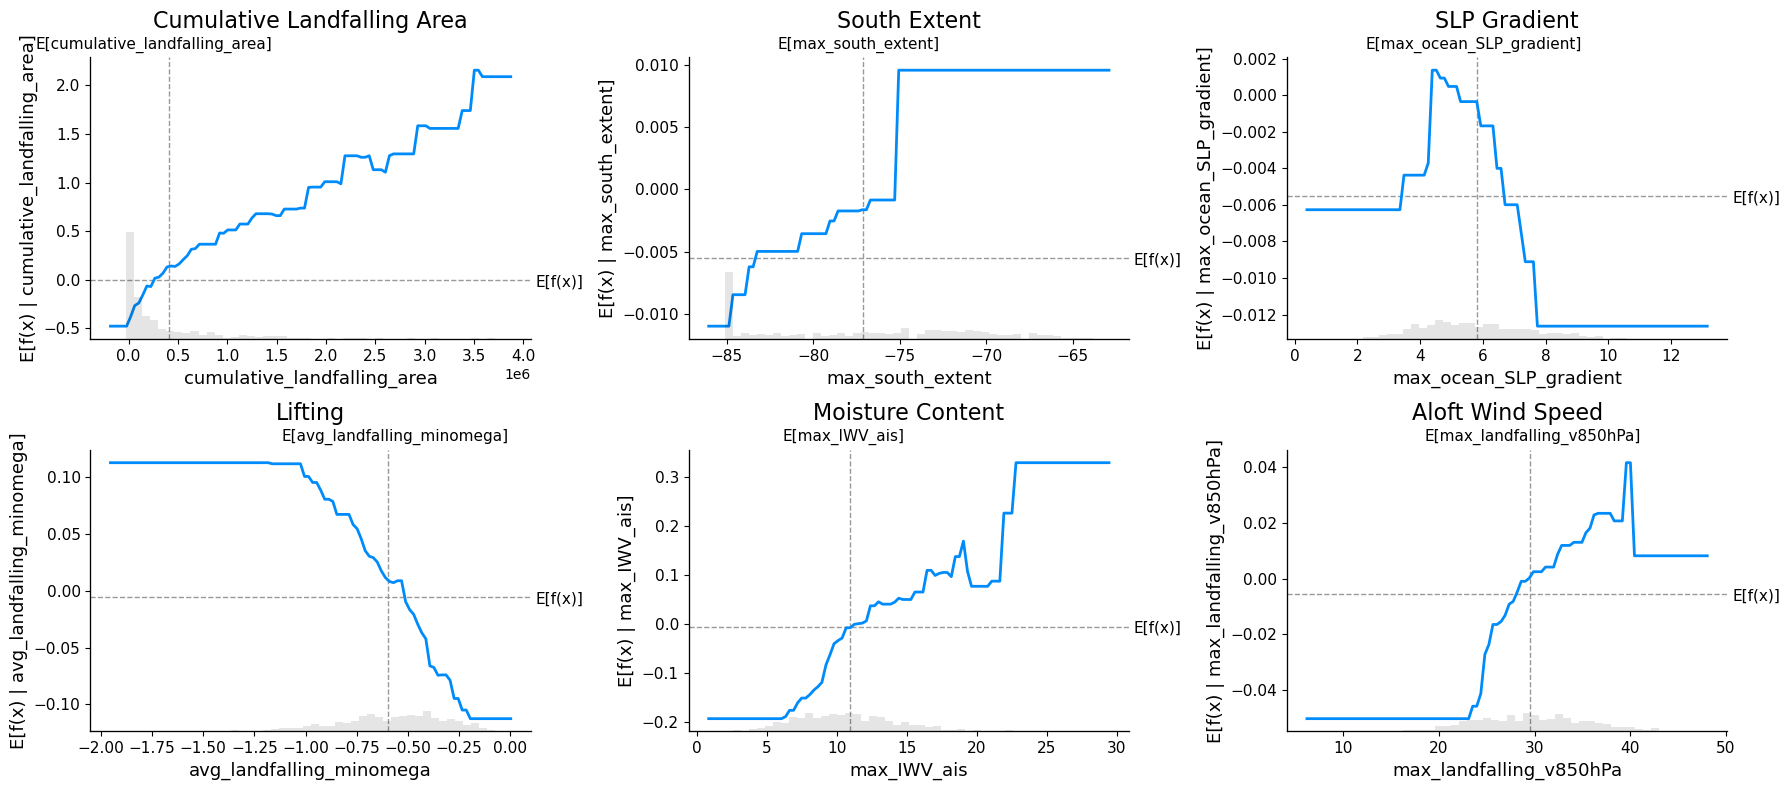

In [69]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 8))

plt.sca(axes[0,0])
shap.partial_dependence_plot(
    "cumulative_landfalling_area",
    fitted.predict,
    X_test,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ax=axes[0,0]
)

axes[0,0].set_title('Cumulative Landfalling Area', fontsize=16);

plt.sca(axes[0,1])
shap.partial_dependence_plot(
    "max_south_extent",
    fitted.predict,
    X_test,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ax=axes[0,1]
)

axes[0,1].set_title('South Extent', fontsize=16);

plt.sca(axes[0,2])
shap.partial_dependence_plot(
    "max_ocean_SLP_gradient",
    fitted.predict,
    X_test,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ax=axes[0,2]
)

axes[0,2].set_title('SLP Gradient', fontsize=16);

plt.sca(axes[1,0])
shap.partial_dependence_plot(
    "avg_landfalling_minomega",
    fitted.predict,
    X_test,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ax=axes[1,0]
)

axes[1,0].set_title('Lifting', fontsize=16);

plt.sca(axes[1,1])
shap.partial_dependence_plot(
    "max_IWV_ais",
    fitted.predict,
    X_test,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ax=axes[1,1]
)

axes[1,1].set_title('Moisture Content', fontsize=16);

plt.sca(axes[1,2])
shap.partial_dependence_plot(
    "max_landfalling_v850hPa",
    fitted.predict,
    X_test,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ax=axes[1,2]
)
axes[1,2].set_title('Aloft Wind Speed', fontsize=16);

plt.tight_layout()
plt.show()

#axes[0,0].set_title('Cumulative Landfalling Area');

In [70]:
shap_values_xgb = explainer_xgb(X_test)

In [75]:
X_test.columns

Index(['max_ocean_SLP_gradient', 'max_landfalling_v850hPa',
       'avg_landfalling_minomega', 'max_IWV_ais',
       'cumulative_landfalling_area', 'max_south_extent'],
      dtype='object')

In [71]:
np.mean(shap_values_xgb.values, axis = 0)

array([-0.00077183,  0.0013534 , -0.00152606,  0.00814148, -0.04667497,
        0.00180151])

In [74]:
np.mean(np.abs(shap_values_xgb.values), axis = 0)

array([0.00502747, 0.01939286, 0.05339372, 0.09437846, 0.37442456,
       0.00988087])

## Temp Model

In [ ]:
final_temp = pd.read_csv('cross_validation/rounds/snow_xgb_round3.csv', index_col=False)